# Project 3A — Aliasing Demonstrator

## What this project does
Demonstrates what happens when you violate the Nyquist theorem —
sampling a signal too slowly causes aliasing, where a high frequency
signal appears as a false lower frequency.

## Key concept
Nyquist theorem: sampling frequency must be at least 2x the signal frequency.
If fs < 2f, aliasing occurs.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [135]:
f_signal = 100
fs_high = 1000
fs_low = 130

t = np.arange(0, 0.1, 1/10000)
signal_true = np.sin(2*np.pi*f_signal*t)

t_oversampled = np.arange(0, 0.1, 1/fs_high)
signal_oversampled = np.sin(2*np.pi*f_signal*t_oversampled)

t_undersampled = np.arange(0, 0.1, 1/fs_low)
signal_undersampled = np.sin(2*np.pi*f_signal*t_undersampled)



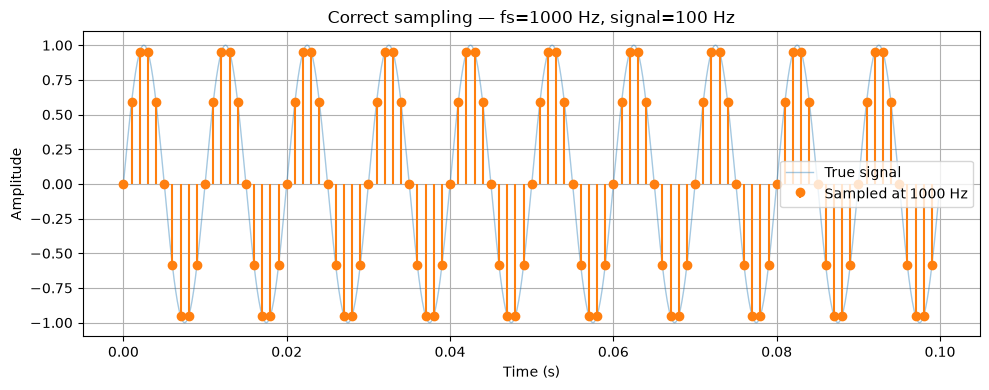

In [136]:
plt.figure(figsize=(10, 4))
plt.plot(t, signal_true, label="True signal", alpha=0.4, linewidth=1)
# true signal shown as faint background reference

plt.stem(t_oversampled, signal_oversampled, linefmt="C1-", markerfmt="C1o", basefmt=" ",
         label=f"Sampled at {fs_high} Hz")
# plt.stem(): plots vertical lines from baseline to each sample point
# linefmt="C1-": line colour and style (C1 = orange, - = solid)
# markerfmt="C1o": marker style (o = circle)
# basefmt=" ": hides the horizontal baseline

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Correct sampling — fs={fs_high} Hz, signal={f_signal} Hz")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

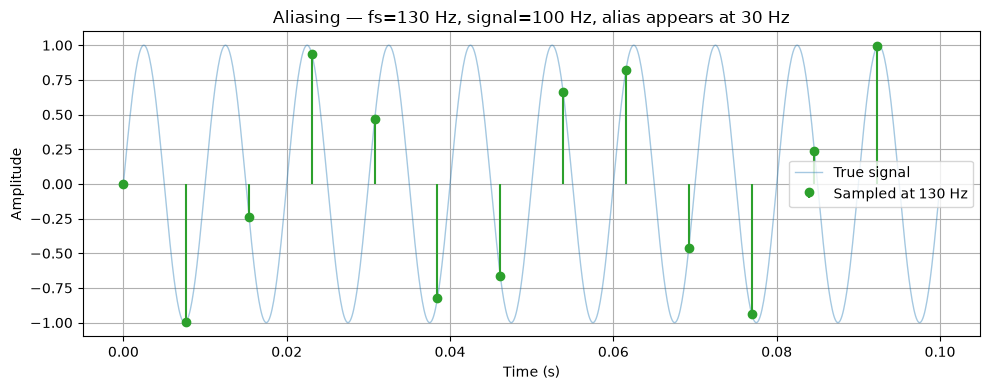

NameError: name 'out' is not defined

In [137]:
plt.figure(figsize=(10,4))

plt.plot(t, signal_true, label="True signal", alpha=0.4, linewidth=1)
plt.stem(t_undersampled, signal_undersampled, linefmt="C2-", markerfmt="C2o", basefmt=" ",
         label=f"Sampled at {fs_low} Hz")

f_alias = abs(f_signal - fs_low)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Aliasing — fs={fs_low} Hz, signal={f_signal} Hz, alias appears at {f_alias} Hz")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
out()
plt.show()

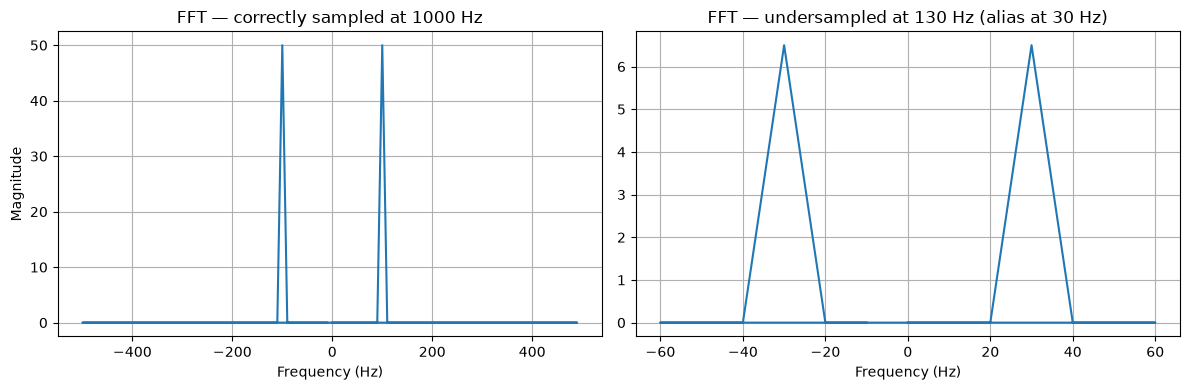

In [138]:
freqs_high = np.fft.fftfreq(len(t_oversampled), 1/fs_high)
fft_high = np.abs(np.fft.fft(signal_oversampled))

freqs_low = np.fft.fftfreq(len(t_undersampled), 1/fs_low)
fft_low = np.abs(np.fft.fft(signal_undersampled))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# plt.subplots(rows, cols): creates a grid of subplots
# (1, 2): 1 row, 2 columns — side by side
# ax1, ax2: individual axes objects for each subplot

ax1.plot(freqs_high, fft_high)
ax1.set_title(f"FFT — correctly sampled at {fs_high} Hz")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude")
ax1.grid(True)
# spike appears at 100 Hz — correct

ax2.plot(freqs_low, fft_low)
ax2.set_title(f"FFT — undersampled at {fs_low} Hz (alias at {f_alias} Hz)")
ax2.set_xlabel("Frequency (Hz)")
ax2.grid(True)
#plt.xlim(0,300)
# spike appears at f_alias Hz — wrong frequency, this is aliasing

plt.tight_layout()
plt.show()

## Key observations
- For correctly sampled plot spike occurs at 100 Hz- For the undersampled FFT spike appears at 30 Hz - A alias frequency match the formula |f_signal - f_s|

## What I learned
- Nyquist theorem: fs must be >= 2 x f_signal to avoid aliasing
- Undersampling makes a high frequency signal appear as a lower false frequency
- This is why audio CDs use 44100 Hz sampling — to capture up to 22050 Hz cleanly